# Spectral Localizer for Boundary Time Crystals (BTCs)

**Dominik Németh**  
_University of Manchester_  
_02 February 2026_

## Build BTC Model

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

1. Build the Liouvillian for the boundary time crystal model,
$ \dot{\rho} = -i[H, \rho] + \dfrac{\Gamma}{N}\Bigl(J_- \rho J_+ - \dfrac{1}{2}\{J_+ J_-, \rho\}\Bigr)$,
where $H=\Omega J_x$.

2. Construct the superoperator $\mathcal X$, which is *`K_rank_mat'* in the code.  *'K_rank_diag'*  is defined as 
$\sum_{k,q} k \ket{k,q}\rangle \langle\bra{k,q}$, where $\ket{k,q}\rangle$ are the eigenvectors of the $\mathcal K ^2$. The eigenvalues of $\mathcal{X}$ correspond to the "position" of the eigenmodes along the k-chain.

In [2]:
# Global model parameters
N_spins   = 10
j         = N_spins / 2.0
omega = 1.0

d = int(2*j + 1)
print(f"j = {j}, Hilbert dim d = {d}")

# Spin operators
Jx = qt.jmat(j, "x")
Jy = qt.jmat(j, "y")
Jz = qt.jmat(j, "z")
Jm = qt.jmat(j, "-")

# Operator space adjoint generators
Kx = qt.spre(Jx) - qt.spost(Jx)
Ky = qt.spre(Jy) - qt.spost(Jy)
Kz = qt.spre(Jz) - qt.spost(Jz)


# Liouvillian builder 
def build_liouvillian(omega: float,  gamma: float) -> np.ndarray:
    H = omega * Jx # Hamiltonian
    c = np.sqrt(gamma / N_spins) * (Jm)  # Collapse operator
    L = qt.liouvillian(H, c_ops=[c])
    return L.full()


# Build K_rank from Casimir K^2; define Q = Kz
K2_mat = (Kx * Kx + Ky * Ky + Kz * Kz).full()
K2_mat = 0.5 * (K2_mat + K2_mat.conj().T)

def build_rank_operator_from_casimir(K2_mat: np.ndarray, j: float) -> np.ndarray:
    evals, U = np.linalg.eigh(K2_mat)
    evals = evals.real

    k_max = int(round(2 * j))
    k_values = np.arange(k_max + 1, dtype=float)
    casimir_vals = k_values * (k_values + 1)

    k_labels = np.zeros_like(evals)
    for i, ev in enumerate(evals):
        idx = int(np.argmin(np.abs(ev - casimir_vals)))
        k_labels[i] = k_values[idx]

    K_rank_diag = np.diag(k_labels)
    K_rank_mat = U @ K_rank_diag @ U.conj().T

    print("Unique k labels:", np.unique(k_labels).astype(int))
    return K_rank_mat

K_rank_mat = build_rank_operator_from_casimir(K2_mat, j)

Q_mat = Kz.full()
Q_mat = 0.5 * (Q_mat + Q_mat.conj().T)

# Hermiticity checks
assert np.allclose(K_rank_mat, K_rank_mat.conj().T, atol=1e-8)
assert np.allclose(Q_mat,      Q_mat.conj().T,      atol=1e-8)

j = 5.0, Hilbert dim d = 11
Unique k labels: [ 0  1  2  3  4  5  6  7  8  9 10]


## Spectral Localizer: standard implementation

Construct the localizer as
$ L_{(x_0,\lambda_0)}(\mathcal{L},\mathcal{X}) =
\mathrm{Re}(\mathcal{L}-\lambda_0\mathbb{I}) \otimes \sigma_x + \mathrm{Im}(\mathcal{L}-\lambda_0\mathbb{I}) \otimes \sigma_y  + \kappa(\mathcal{X}-x_0\mathbb{I}) \otimes \sigma_z $

Index is $\nu^{L}_{(x_0,\lambda_0)}= \frac{1}{2}\mathrm{sig}\Bigl[L_{(x_0,\lambda_0)}\Bigr]$
and the localizer gap is $\mu_{(x_0,\lambda_0)}=\min\Bigl\{\,|\lambda|:\lambda\in \mathrm{spec}\bigl(L_{(x_0,\lambda_0)}\bigr)\Bigr\}$

In [3]:
def spectral_localizer(L_mat: np.ndarray, X: np.ndarray, lam0: complex, x0: float, kappa: float) -> np.ndarray:
    N = L_mat.shape[0]
    I = np.eye(N, dtype=complex)

    A = L_mat - lam0 * I
    A1 = 0.5 * (A + A.conj().T)
    A2 = -0.5j * (A - A.conj().T)
    A3 = kappa * (X - x0 * I)

    # Pauli matrices for the localizer
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sz = np.array([[1, 0], [0, -1]], dtype=complex)

    L_loc = np.kron(A1, sx) + np.kron(A2, sy) + np.kron(A3, sz)

    if not np.allclose(L_loc, L_loc.conj().T, atol=1e-8):
        raise ValueError("Localizer is not Hermitian. Check inputs.")
    return L_loc

def localizer_gap_and_index(L_loc: np.ndarray, zero_tol: float = 1e-8):
    evals = np.linalg.eigvalsh(L_loc)
    mu = float(np.min(np.abs(evals)))
    pos = np.sum(evals >  zero_tol)
    neg = np.sum(evals < -zero_tol)
    
    # assert integer values for pos and neg counts
    assert pos == int(pos)
    assert neg == int(neg)

    sig = int(pos - neg)
    idx = int(sig // 2)
    return mu, idx

# Quick sanity print
L0 = build_liouvillian(omega, gamma=1.0)
print(f"Liouville dimension N_liou = {L0.shape[0]}")

Liouville dimension N_liou = 121


## Spectral Localizer: FAST implementation

Here, we implement a faster version of the spectral localizer by using an $LDL^T$ decomposition and making use of Sylvester's Law of Inertia.

A Hermitian matrix defines a quadratic form,
$ Q(\boldsymbol x) = \boldsymbol x^T H \boldsymbol x $,
which under a change of basis $x=Sy$ becomes,
$ Q(\boldsymbol y) = \boldsymbol y^T (S^T H S) \boldsymbol y  = \boldsymbol y^T D \boldsymbol y$.

The matrices $H$ and $D$ are said to be to congruent matrices if they satisify the transformation above. Congruent matrices define the same quadratic form $Q$ but expressed in different bases.

**Sylvester's Law of Inertia** states that a congruence transformation preserves the *inertia* (the number of positive, negative and zero eigenvalues) of a matrix. This implies that the *signature* (the difference between the number of positive and negative eigenvalues) remains the same.

The $LDL^T$ decomposition then produces,
$H  = L D L^T$,
such that 
$L =$ a lower/upper triangular matrix and $D =$ a block diagonal matrix with blocks of size at most 2x2. Finding the signature of the matrix $D$ is numerically faster than doing so for the matrix $H$.

This method may be used as a faster implementation of calculating $\nu^L$.

In [ ]:
import numpy as np
import scipy.linalg as sla
from joblib import Parallel, delayed

# FAST localizer index via block form + LDL inertia

class LocalizerPrecomp:
    """
    Precompute gamma-dependent pieces so each x0 update is O(N) + LDL factorization.
    L_loc(x0) = [[ kappa(X - x0 I),  A ],
                [ A†            , -kappa(X - x0 I) ]]
    where A = L - lam0 I.
    """
    def __init__(self, L_mat: np.ndarray, X: np.ndarray, lam0: complex, kappa: float):
        self.N = int(L_mat.shape[0])
        self.kappa = float(kappa)

        N = self.N
        I = np.eye(N, dtype=complex)

        # A = L - lam0 I
        A = L_mat.astype(complex, copy=False) - lam0 * I
        Ad = A.conj().T

        # Hermitian safety for X
        Xh = 0.5 * (X + X.conj().T)
        Xk = self.kappa * Xh.astype(complex, copy=False)
        # print operator norms for sanity check
        print(f"||A|| = {np.linalg.norm(A):.3e}, ||Xk|| = {np.linalg.norm(Xk):.3e}")

        # Base localizer at x0=0
        L0 = np.empty((2 * N, 2 * N), dtype=complex)
        L0[:N, :N] = Xk
        L0[:N, N:] = A
        L0[N:, :N] = Ad
        L0[N:, N:] = -Xk

        self.L_work = L0
        self._x0_current = 0.0

        # Diagonal indices for in-place updates
        ii = np.arange(N)
        self._tl = (ii, ii)                 # top-left diag (within TL block)
        self._br = (N + ii, N + ii)         # bottom-right diag (within BR block)

    def set_x0(self, x0: float):
        x0 = float(x0)
        dx = x0 - self._x0_current
        if dx == 0.0:
            return
        shift = self.kappa * dx
        # TL:  kappa(X - x0 I) => subtract kappa*dx on diagonal
        # BR: -kappa(X - x0 I) => add      kappa*dx on diagonal
        self.L_work[self._tl] -= shift
        self.L_work[self._br] += shift
        self._x0_current = x0

    def matrix(self) -> np.ndarray:
        return self.L_work


def inertia_from_ldl_D(D: np.ndarray, tol: float = 1e-10):
    """
    D from SciPy LDL(H) can contain 1x1 and 2x2 pivot blocks.
    Count sign of the eigenvalues of D without diagonalizing full matrix.
    """
    n = D.shape[0]
    pos = neg = zero = 0
    i = 0
    eps2 = 1e-14  # detect 2x2 coupling

    while i < n:
        if i < n - 1 and (abs(D[i+1, i]) > eps2 or abs(D[i, i+1]) > eps2):
            blk = D[i:i+2, i:i+2]
            ev = np.linalg.eigvalsh(blk).real
            pos += int(np.sum(ev >  tol))
            neg += int(np.sum(ev < -tol))
            zero += int(2 - (np.sum(ev > tol) + np.sum(ev < -tol)))
            i += 2
        else:
            d = float(np.real(D[i, i]))
            if d > tol:
                pos += 1
            elif d < -tol:
                neg += 1
            else:
                zero += 1
            i += 1

    return pos, neg, zero


def localizer_index_ldl(L_loc: np.ndarray, zero_tol: float = 1e-10) -> int:
    """
    Index from signature using LDL(H) inertia:
      idx = (pos - neg)//2
    """
    _, D, _ = sla.ldl(L_loc, hermitian=True)
    pos, neg, _ = inertia_from_ldl_D(D, tol=zero_tol)
    return -int((pos - neg) // 2) # - sign to match convention of other implementation


def idx_at_x0(pre: LocalizerPrecomp, x0: float, zero_tol: float) -> int:
    pre.set_x0(x0)
    return localizer_index_ldl(pre.matrix(), zero_tol=zero_tol)



# ADAPTIVE x0 sweep
def adaptive_index_sweep(L_mat: np.ndarray, X: np.ndarray, lam0: complex,
                         x_min: float, x_max: float,
                         kappa: float, zero_tol: float,
                         n_coarse: int = 60,
                         max_refine: int = 10,
                         refine_only_changes: bool = True):
    """
    Returns:
      x_sorted: nonuniform x-grid (1D array)
      idx_sorted: index values at those points
    Strategy:
      - coarse uniform grid
      - repeatedly insert midpoints only on intervals where index changes
    """
    pre = LocalizerPrecomp(L_mat, X, lam0=lam0, kappa=kappa)

    x = np.linspace(float(x_min), float(x_max), int(n_coarse))
    idx = np.empty_like(x, dtype=int)

    # Evaluate coarse grid 
    pre.set_x0(x[0])
    idx[0] = localizer_index_ldl(pre.matrix(), zero_tol=zero_tol)
    for i in range(1, len(x)):
        idx[i] = idx_at_x0(pre, x[i], zero_tol=zero_tol)

    # Refinement loop
    for _ in range(int(max_refine)):
        # Find where the step changes between adjacent samples
        change = np.where(idx[:-1] != idx[1:])[0]
        if change.size == 0:
            break

        mids = 0.5 * (x[change] + x[change + 1])

        # set refine_only_changes=False.
        if not refine_only_changes:
            mids = 0.5 * (x[:-1] + x[1:])

        # Remove duplicates
        mids = np.unique(mids)

        # Evaluate new points
        mids.sort()
        mid_idx = np.empty_like(mids, dtype=int)

        pre.set_x0(mids[0])
        mid_idx[0] = localizer_index_ldl(pre.matrix(), zero_tol=zero_tol)
        for i in range(1, len(mids)):
            mid_idx[i] = idx_at_x0(pre, mids[i], zero_tol=zero_tol)

        # Merge (x, idx) with (mids, mid_idx)
        x = np.concatenate([x, mids])
        idx = np.concatenate([idx, mid_idx])
        order = np.argsort(x)
        x = x[order]
        idx = idx[order]

    return x, idx


# PARALLEL over gamma
def compute_idx_curve_for_gamma(gamma: float,
                                omega: float,
                                build_liouvillian_fn,
                                X: np.ndarray,
                                lam0: complex,
                                x_min: float, x_max: float,
                                kappa: float, zero_tol: float,
                                n_coarse: int, max_refine: int):
    """
    Worker: builds L for this gamma, runs adaptive sweep, returns (gamma, x, idx).
    """
    L_mat = build_liouvillian_fn(omega, gamma)
    x, idx = adaptive_index_sweep(
        L_mat, X, lam0=lam0,
        x_min=x_min, x_max=x_max,
        kappa=kappa, zero_tol=zero_tol,
        n_coarse=n_coarse, max_refine=max_refine
    )
    return gamma, x, idx

# Basic Diagnostics

## Varying $\Gamma$

k0 range: [-0.000, 10.000]


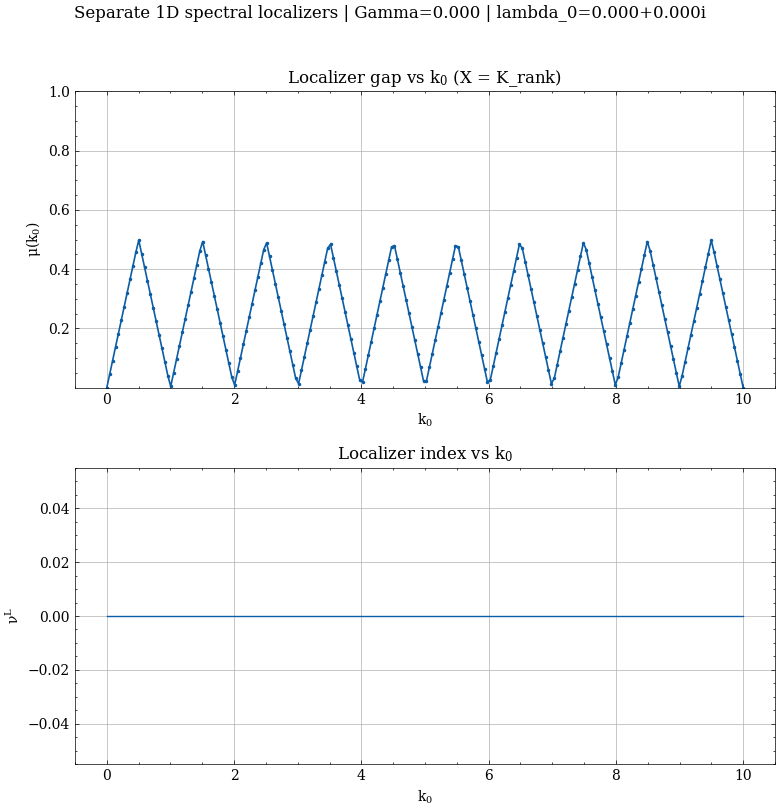

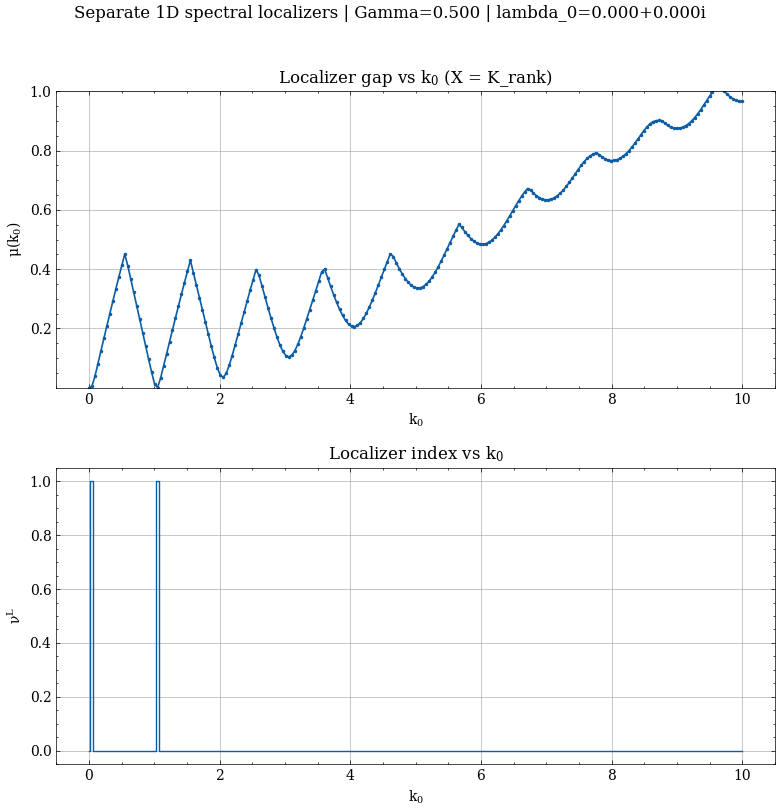

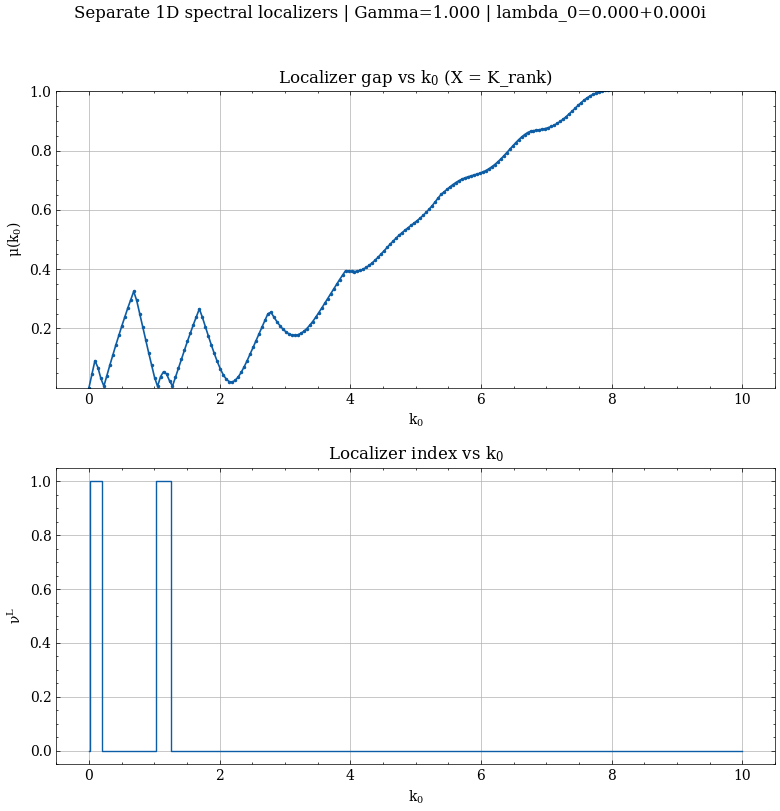

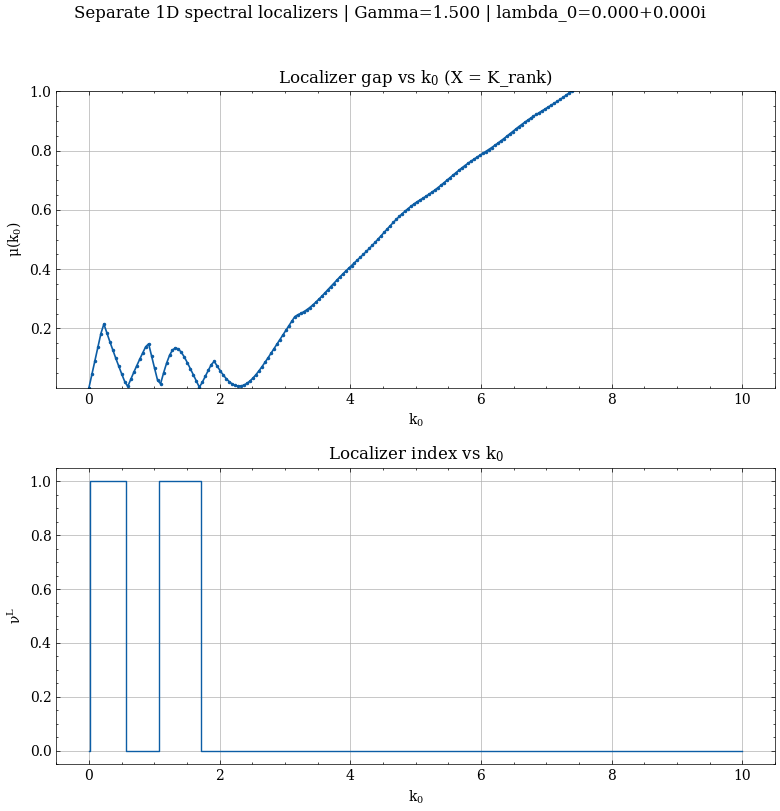

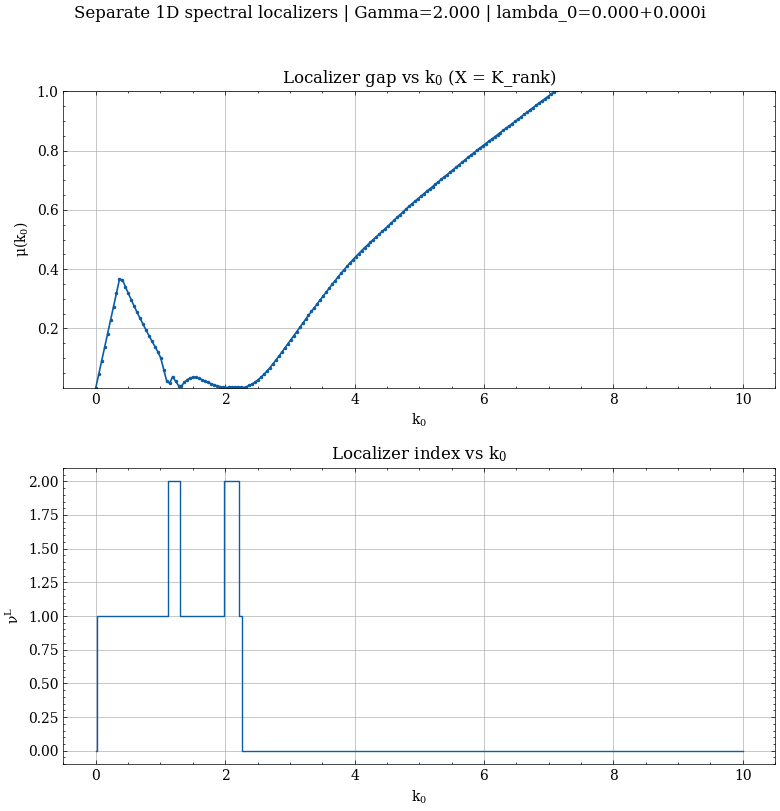


Gamma scan done.


In [15]:
# Force NO TeX even if a style turns it on
mpl.rcParams.update({
    "text.usetex": False,
    "mathtext.default": "regular",
})

gamma_vals = np.linspace(0.0, 2.0, 5)

# spectral probe choice
lam0_fixed = 0.0 + 0.0j

# scan grid sizes
Nk = 20 * (N_spins + 1)

kappa_k = 1
zero_tol = 1e-8

# build scan grid from eigenvalue ranges
k_eigs = np.linalg.eigvalsh(K_rank_mat).real

k0_vals = np.linspace(float(k_eigs.min()), float(k_eigs.max()), Nk)

print(f"k0 range: [{k0_vals.min():.3f}, {k0_vals.max():.3f}]")

for gamma in gamma_vals:
    lam0 = lam0_fixed
    L_mat = build_liouvillian(omega, gamma)

    # scan along coordinate k
    mu_k  = np.zeros(Nk, dtype=float)
    idx_k = np.zeros(Nk, dtype=int)

    for i, k0 in enumerate(k0_vals):
        L_loc = spectral_localizer(L_mat, K_rank_mat, lam0=lam0, x0=k0, kappa=kappa_k)
        mu, idx = localizer_gap_and_index(L_loc, zero_tol=zero_tol)
        mu_k[i]  = mu
        idx_k[i] = idx

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(8, 8))

    axes[0].plot(k0_vals, mu_k, lw=1.2, marker='.', markersize=3)
    #axes[0, 0].set_yscale("log")
    axes[0].set_ylim(1e-4, 1e0)
    axes[0].set_xlabel("$k_0$")
    axes[0].set_ylabel("$\\mu(k_0)$")
    axes[0].set_title("Localizer gap vs $k_0$ (X = K_rank)")
    axes[0].grid(True)

    axes[1].step(k0_vals, idx_k, where="mid")
    axes[1].set_xlabel("$k_0$")
    axes[1].set_ylabel("$\\nu^L$")
    axes[1].set_title("Localizer index vs $k_0$")
    axes[1].grid(True)

    plt.suptitle(
        f"Separate 1D spectral localizers | Gamma={gamma:.3f} | "
        f"lambda_0={lam0.real:.3f}+{lam0.imag:.3f}i",
        y=1.02
    )
    plt.tight_layout()
    plt.show()

print("\nGamma scan done.")

## Varying $\kappa$

/var/folders/pm/kn6krmsd6wl42_yz8gyqb2580000gn/T/ipykernel_6073/1149826430.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


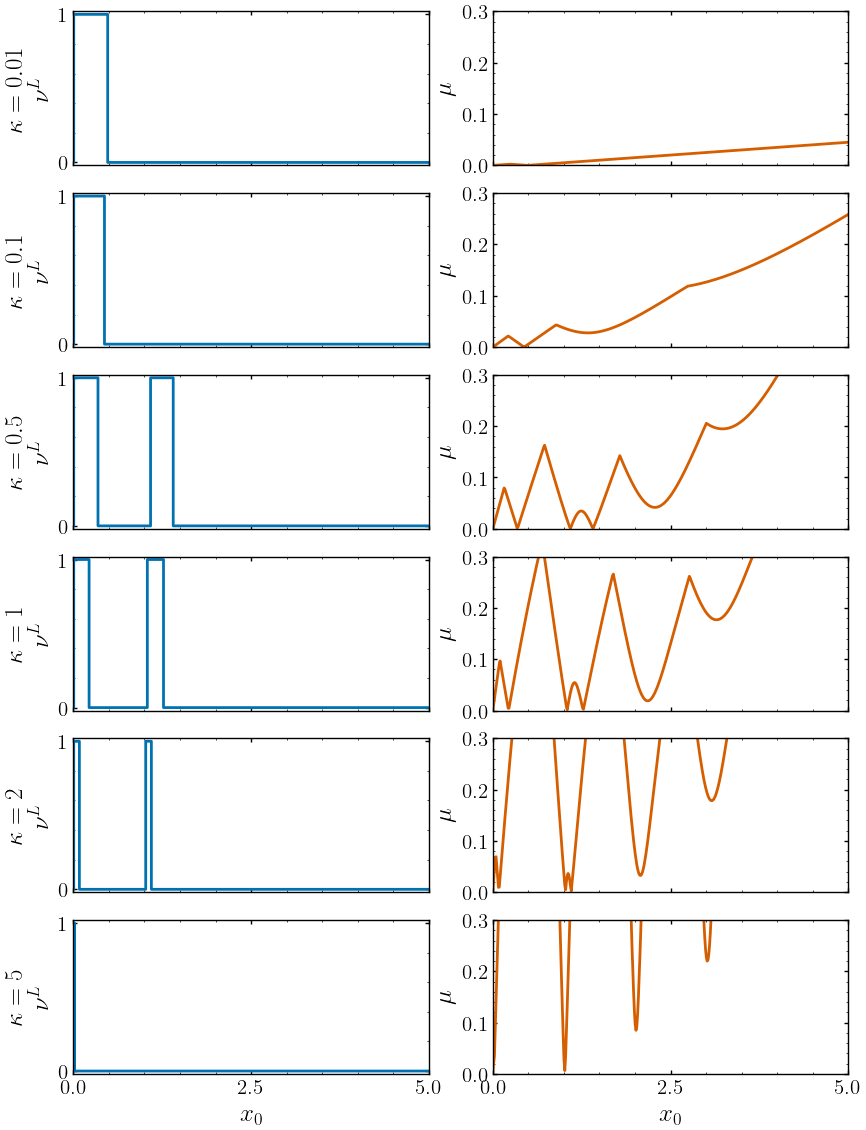

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

try:
    import scienceplots
    plt.style.use("science")
except Exception:
    pass

# Font + tick styling
mpl.rcParams.update({
    "text.usetex": True,
    "mathtext.default": "regular",
    "font.size": 15,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

gamma = 1.0
kappa_vals = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]

lam0 = 0.0 + 0.0j
zero_tol = 1e-8
Nk = 80 * (N_spins + 1)

# coordinate grid
k_eigs = np.linalg.eigvalsh(K_rank_mat).real
k0_vals = np.linspace(float(k_eigs.min()), float(k_eigs.max()), Nk)

L_mat = build_liouvillian(omega, gamma)


mu_all, idx_all = [], []

for kappa_k in kappa_vals:
    mu_k  = np.zeros(Nk)
    idx_k = np.zeros(Nk, dtype=int)

    for i, k0 in enumerate(k0_vals):
        L_loc = spectral_localizer(L_mat, K_rank_mat,
                                   lam0=lam0, x0=k0, kappa=kappa_k)
        mu, idx = localizer_gap_and_index(L_loc, zero_tol=zero_tol)
        mu_k[i], idx_k[i] = mu, idx

    mu_all.append(mu_k)
    idx_all.append(idx_k)

mu_all  = np.array(mu_all)
idx_all = np.array(idx_all)


# Vertical layout
nK = len(kappa_vals)

fig, axes = plt.subplots(
    nK, 2,
    figsize=(10, 2.3*nK),
    sharex=True,
    gridspec_kw=dict(hspace=0.18, wspace=0.18)
)

# Better colours 
index_color = "#0072B2"   # blue
gap_color   = "#D55E00"   # vermillion

for i, kappa_k in enumerate(kappa_vals):

    ax_idx = axes[i, 0]
    ax_mu  = axes[i, 1]

    # Index (left)
    ax_idx.step(k0_vals, idx_all[i],
                where="mid",
                lw=2.0,
                color=index_color)

    ax_idx.set_xlim(0, 5)
    ax_idx.set_xticks([0, 2.5, 5])
    ax_idx.set_ylim(-0.02, 1.02)
    ax_idx.set_yticks([0, 1])
    ax_idx.set_ylabel(rf"$\kappa={kappa_k:g}$" + "\n" + r"$\nu^L$")

    # Gap (right)
    ax_mu.plot(k0_vals, mu_all[i],
               lw=2.0,
               color=gap_color)

    ax_mu.set_xlim(0, 5)
    ax_mu.set_xticks([0, 2.5, 5])
    ax_mu.set_ylim(0, 0.3)
    ax_mu.set_yticks([0, 0.1, 0.2, 0.3])
    ax_mu.set_ylabel(r"$\mu$")

# Only bottom row gets x-label
axes[-1, 0].set_xlabel(r"$x_0$")
axes[-1, 1].set_xlabel(r"$x_0$")

# Remove grid everywhere
for ax in axes.flatten():
    ax.grid(False)

plt.tight_layout()
FILE_NAME = 'localizer_kappa_scan_' + f'N_{N_spins}' + f'gamma_{gamma}'
#plt.savefig(FILE_NAME + '.png', dpi=300)
plt.show()

done κ=0.01 | ν unique=[0]
done κ=0.1 | ν unique=[0 1]
done κ=0.5 | ν unique=[0 1]
done κ=1 | ν unique=[0 1]
done κ=2 | ν unique=[0 1]
done κ=5 | ν unique=[0 1]


/var/folders/pm/kn6krmsd6wl42_yz8gyqb2580000gn/T/ipykernel_25883/3686559715.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


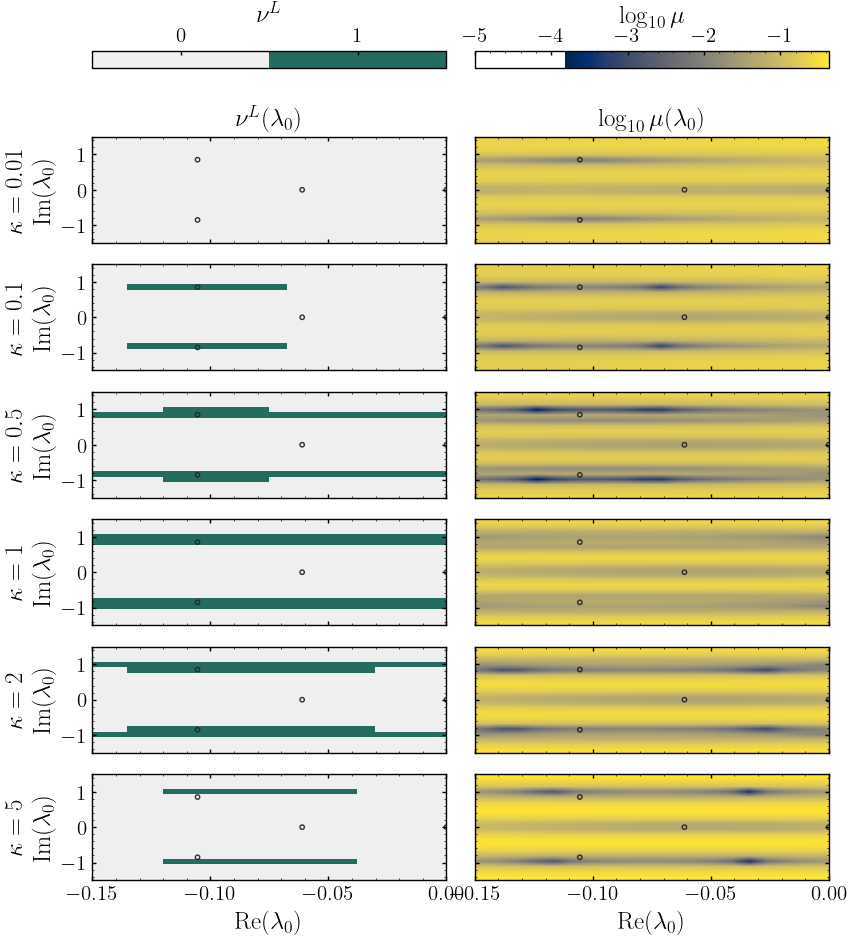

In [16]:
from matplotlib.colors import ListedColormap, BoundaryNorm


try:
    import scienceplots
    plt.style.use(["science"])
except Exception:
    pass

# ---- Font + tick styling ----
mpl.rcParams.update({
    "text.usetex": True,
    "mathtext.default": "regular",
    "font.size": 15,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


gamma     = 1.0
kappa_vals = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]

X = K_rank_mat
x0        = 1.0
zero_tol  = 1e-8

re_grid = np.linspace(-0.15, 0, 20)
im_grid = np.linspace(-1.5, 1.5, 20)

# Build L 
L_mat = build_liouvillian(omega, gamma=gamma)
lam   = np.linalg.eigvals(L_mat)

palette = [
    (0.94, 0.94, 0.94, 1.0),  # 0  -> light gray
    (0.15, 0.42, 0.38, 1.0),  # +1 -> teal
    (0.20, 0.20, 0.20, 1.0),  # -1 -> charcoal
]
val_to_color = {0: palette[0], 1: palette[1], -1: palette[2]}


MU_all  = []
IDX_all = []
unique_vals_global = set()

for kappa in kappa_vals:
    MU  = np.zeros((len(im_grid), len(re_grid)), dtype=float)
    IDX = np.zeros((len(im_grid), len(re_grid)), dtype=int)

    for yi, im0 in enumerate(im_grid):
        for xi, re0 in enumerate(re_grid):
            lam0 = re0 + 1j * im0
            L_loc = spectral_localizer(L_mat, X, lam0=lam0, x0=x0, kappa=kappa)
            mu, idx = localizer_gap_and_index(L_loc, zero_tol=zero_tol)
            MU[yi, xi]  = mu
            IDX[yi, xi] = idx

    MU_all.append(MU)
    IDX_all.append(IDX)
    unique_vals_global |= set(np.unique(IDX).tolist())

    print(f"done κ={kappa:g} | "
          f"ν unique={np.unique(IDX)}")

MU_all  = np.array(MU_all)  
IDX_all = np.array(IDX_all)  

# Build global discrete cmap so colors are consistent across rows
unique_vals_global = np.array(sorted(list(unique_vals_global)))
colors_used = [val_to_color[v] for v in unique_vals_global]
cmap_idx = ListedColormap(colors_used)
bounds = np.concatenate([unique_vals_global - 0.5, [unique_vals_global[-1] + 0.5]])
norm_idx = BoundaryNorm(bounds, cmap_idx.N)

# Shared color scaling for the gap map
LOGMU_all = np.log10(np.maximum(MU_all, 1e-16))
vmin_gap  = float(np.min(LOGMU_all))
vmax_gap  = float(np.max(LOGMU_all))


nK = len(kappa_vals)

fig, axes = plt.subplots(
    nK, 2,
    figsize=(9.5, 1.85*nK),
    sharex=True, sharey=True,
    gridspec_kw=dict(hspace=0.2, wspace=0.08)
)

extent = [re_grid.min(), re_grid.max(),
          im_grid.min(), im_grid.max()]

for i, kappa in enumerate(kappa_vals):
    axL = axes[i, 0]
    axR = axes[i, 1]

    # Index panel 
    imA = axL.imshow(
        IDX_all[i],
        origin="lower", aspect="auto",
        extent=extent,
        cmap=cmap_idx, norm=norm_idx,
        interpolation="nearest"
    )

    axL.scatter(lam.real, lam.imag, s=10, alpha=0.95,
        facecolors="none",
        edgecolors=(0.15, 0.15, 0.15, 0.8),
        linewidths=1.0
    )
    # κ in y-label
    axL.set_ylabel(
        rf"$\kappa={kappa:g}$" + "\n" + r"Im($\lambda_0$)"
    )
    axL.set_xlim(re_grid.min(), re_grid.max())
    axL.set_ylim(im_grid.min(), im_grid.max())
    #axL.set_xticks([-0.08, -0.04])  # only bottom row gets x-ticks


    #  Gap panel
    imB = axR.imshow(
        LOGMU_all[i],
        origin="lower", aspect="auto",
        extent=extent,
        cmap="cividis",
        vmin=vmin_gap, vmax=vmax_gap,
        interpolation="bilinear"
    )

    axR.scatter(lam.real, lam.imag,s=10, alpha=0.95,
        facecolors="none",
        edgecolors=(0.15, 0.15, 0.15, 0.8),
        linewidths=1.0
    )
    # remove redundant y-label on right
    axR.set_ylabel("")

    axR.set_xlim(re_grid.min(), re_grid.max())
    axR.set_ylim(im_grid.min(), im_grid.max())
    #axR.set_xticks([-0.08, -0.04])  # only bottom row gets x-ticks

 

# Bottom x-labels
axes[-1, 0].set_xlabel(r"Re($\lambda_0$)")
axes[-1, 1].set_xlabel(r"Re($\lambda_0$)")

# Column headers
axes[0, 0].set_title(r"$\nu^L(\lambda_0)$", pad=8)
axes[0, 1].set_title(r"$\log_{10}\mu(\lambda_0)$", pad=8)

# Top horizontal colorbars
# Index colorbar (top of left column)
cbarA = fig.colorbar(
    imA,
    ax=axes[:, 0],
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    location="top"
)
cbarA.set_ticks(unique_vals_global)
cbarA.set_label(r"$\nu^L$")

# Gap colorbar (top of right column)
cbarB = fig.colorbar(
    imB,
    ax=axes[:, 1],
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    location="top"
)
cbarB.set_label(r"$\log_{10}\mu$")
cbarB.set_ticks([-5, -4,-3, -2, -1])
plt.tight_layout()
plt.show()

# Main Results

## Steady-State Delocalization across the k-chain

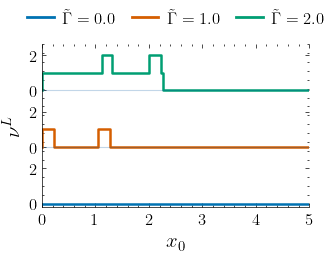

In [17]:
plt.style.use("science")

gamma_list = [0.0, 1, 2]
lam0 = 0.0 + 0.0j

Nx = 25 * (N_spins + 1)
kappa = 1
zero_tol = 1e-10          

k_eigs = np.linalg.eigvalsh(K_rank_mat).real
x0_vals = np.linspace(0.0, 5.0, Nx)

line_colours = ["#0072B2", "#D55E00", "#009E73"]

# compute indices
idx_data = {}
for gamma in gamma_list:
    L_mat = build_liouvillian(omega, gamma)
    idx_k = np.zeros(Nx, dtype=int)
    for i, x0 in enumerate(x0_vals):
        L_loc = spectral_localizer(L_mat, K_rank_mat, lam0=lam0, x0=x0, kappa=kappa)
        _, idx = localizer_gap_and_index(L_loc, zero_tol=zero_tol)
        idx_k[i] = idx
    idx_data[gamma] = idx_k

# stacked plot
fig, ax = plt.subplots(figsize=(3.4, 2.6))

lane_height = 3.2

for j, gamma in enumerate(gamma_list):
    y = idx_data[gamma] + j * lane_height
    ax.step(x0_vals, y, where="mid", lw=1.8, color=line_colours[j])


# separators between lanes
for j in range(1, len(gamma_list)):
    ax.axhline(j * lane_height, lw=0.8, alpha=0.25)

# repeated integer ticks
yticks, yticklabels = [], []
for j in range(len(gamma_list)):
    for val in [0, 2]:
        yticks.append(j * lane_height + val)
        yticklabels.append(str(val))

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

ax.set_xlim(0.0, 5.0)
ax.set_ylim(
    -0.2,
    lane_height * (len(gamma_list) - 1) + 2.6
)
ax.set_xlabel(r"$x_0$", fontsize=15)
ax.set_ylabel(r"$\nu^L$", fontsize=15)

handles = [
    plt.Line2D([0], [0], color=line_colours[j], lw=2)
    for j in range(len(gamma_list))
]
labels = [fr"$\tilde\Gamma={g/(omega):.1f}$" for g in gamma_list]


ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(gamma_list),
    frameon=False,
    fontsize=12,
    handlelength=1.6,
    columnspacing=1.0,
    handletextpad=0.5,
)

# increase size of ticks and labels
ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout(pad=0.3)
plt.show()


||A|| = 8.065e+01, ||Xk|| = 8.022e+01||A|| = 5.866e+01, ||Xk|| = 8.022e+01
||A|| = 4.919e+01, ||Xk|| = 8.022e+01



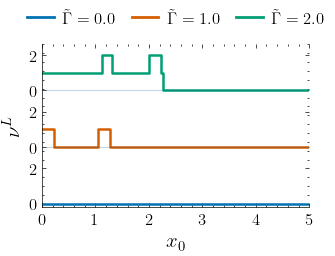

In [31]:
plt.style.use("science")

gamma_list = [0.0, 1, 2]
lam0 = 0 + 0.0j
kappa = 1
zero_tol = 1e-10      

# Choose adaptive controls
n_coarse = 100       
max_refine = 10 

# Parallel compute curves 
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(compute_idx_curve_for_gamma)(
        gamma, omega, build_liouvillian, K_rank_mat, lam0,
        x_min=0.0, x_max=5.0,
        kappa=kappa, zero_tol=zero_tol,
        n_coarse=n_coarse, max_refine=max_refine
    )
    for gamma in gamma_list
)

# Pack results in a dict keyed by gamma
idx_data = {g: (x, idx) for (g, x, idx) in results}

# PLOT 
line_colours = ["#0072B2", "#D55E00", "#009E73"]

fig, ax = plt.subplots(figsize=(3.4, 2.6))
lane_height = 3.2

for j, gamma in enumerate(gamma_list):
    x, idx = idx_data[gamma]
    y = idx + j * lane_height
    ax.step(x, y, where="mid", lw=1.8, color=line_colours[j])

for j in range(1, len(gamma_list)):
    ax.axhline(j * lane_height, lw=0.8, alpha=0.25)

yticks, yticklabels = [], []
for j in range(len(gamma_list)):
    for val in [0, 2]:
        yticks.append(j * lane_height + val)
        yticklabels.append(str(val))

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

ax.set_xlim(0.0, 5.0)
ax.set_ylim(-0.2, lane_height * (len(gamma_list) - 1) + 2.6)
ax.set_xlabel(r"$x_0$", fontsize=15)
ax.set_ylabel(r"$\nu^L$", fontsize=15)

handles = [plt.Line2D([0], [0], color=line_colours[j], lw=2) for j in range(len(gamma_list))]
labels = [fr"$\tilde\Gamma={g/(omega):.1f}$" for g in gamma_list]

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(gamma_list),
    frameon=False,
    fontsize=12,
    handlelength=1.6,
    columnspacing=1.0,
    handletextpad=0.5,
)

ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout(pad=0.3)
plt.show()

## Eigenmode Profiles and Delocalization

Don't forget to re run the cells at the top.

(k,q) basis built. Orthonormality ||B†B-I|| = 1.62e-14
k sectors present: [ 0  1  2  3  4  5  6  7  8  9 10]


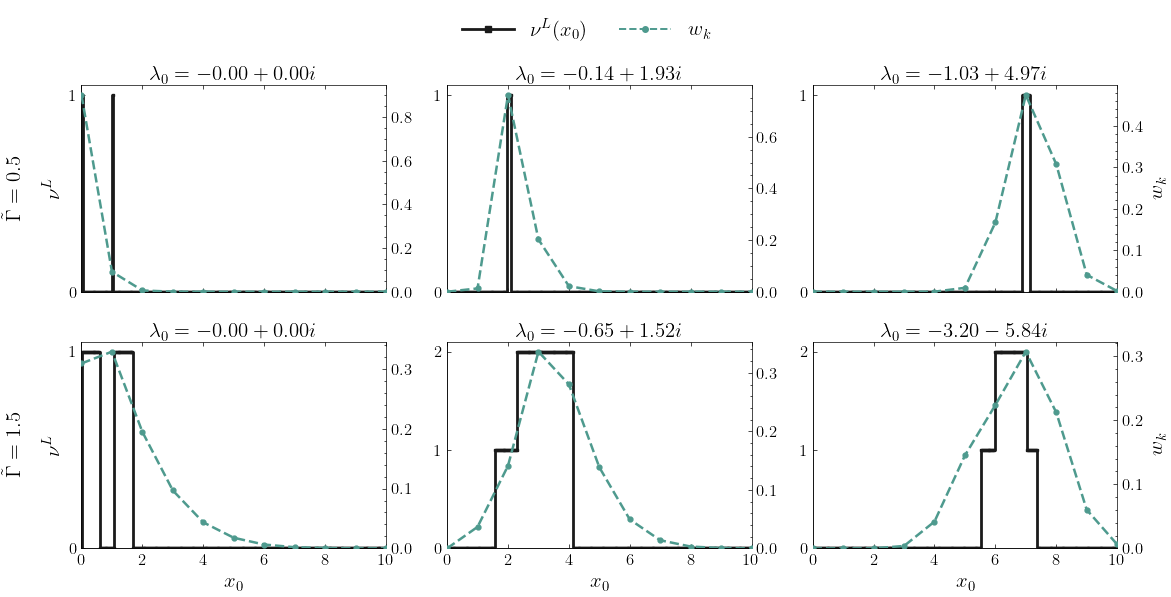

In [ ]:
plt.style.use("science")

index_color = "#1a1a1a"
rank_color  = "#4E9A8E"

x0_min, x0_max = 0.0, float(int(2*j))
Nx0 = 30 * (N_spins + 1)
kappa = 1
zero_tol = 1e-8


def build_kq_basis_from_casimir_and_Q(K2_mat: np.ndarray, Q_mat: np.ndarray, j: float,
                                     tol_match: float = 1e-8):
    # Hermitian safety
    K2 = 0.5 * (K2_mat + K2_mat.conj().T)
    Q  = 0.5 * (Q_mat  + Q_mat.conj().T)

    # Diagonalize K^2
    evals, U = np.linalg.eigh(K2)  # U columns are eigenvectors
    evals = evals.real

    # Allowed k and casimir eigenvalues
    k_max = int(round(2*j))
    k_values = np.arange(k_max + 1, dtype=float)
    casimir_vals = k_values * (k_values + 1)

    # Assign each K^2 eigenvector a k label
    k_labels = np.zeros_like(evals)
    for i, ev in enumerate(evals):
        idx = int(np.argmin(np.abs(ev - casimir_vals)))

        k_labels[i] = k_values[idx]

    k_values_present = np.unique(k_labels).astype(int)
    k_values_present.sort()

    # Now within each k-degenerate sector, diagonalize Q restricted to that sector
    basis_vectors = []
    labels = []

    for k in k_values_present:
        idxs = np.where(k_labels == k)[0]
        V = U[:, idxs]  # columns span O_k, orthonormal

        # Restrict Q to this subspace: Q_k = V^† Q V
        Qk = V.conj().T @ Q @ V
        q_evals, W = np.linalg.eigh(Qk)  # W columns are eigenvectors in this subspace
        q_evals = q_evals.real

        # Lift back: |k, q_i) = V |w_i)
        Bk = V @ W  # N x (2k+1), orthonormal columns

        # q should be integer in {-k,...,+k}; match by nearest integer
        q_targets = np.arange(-k, k+1, dtype=int)
        q_labels = []
        for ev in q_evals:
            q_labels.append(int(q_targets[np.argmin(np.abs(ev - q_targets))]))

        # Sort columns by q ascending for nice ordering
        order = np.argsort(q_labels)
        for t in order:
            basis_vectors.append(Bk[:, t])
            labels.append((int(k), int(q_labels[t])))

    # orthonormality of the full basis
    B = np.column_stack(basis_vectors)  # N x N
    err = np.linalg.norm(B.conj().T @ B - np.eye(B.shape[1]))
    print(f"(k,q) basis built. Orthonormality ||B†B-I|| = {err:.2e}")
    print("k sectors present:", k_values_present)

    return basis_vectors, labels, k_values_present


def sort_modes_steady_then_absRe(evals, R):
    """Put steady state first, then sort by increasing |Re(λ)| (tie-break |Im|, then |λ|)."""
    steady = int(np.argmin(np.abs(evals)))
    idx = np.arange(len(evals))
    rest = idx[idx != steady]
    rest_sorted = rest[np.lexsort((
        np.abs(evals[rest]),          # tertiary
        np.abs(evals[rest].imag),     # secondary
        np.abs(evals[rest].real),     # primary
    ))]
    perm = np.concatenate(([steady], rest_sorted))
    return evals[perm], R[:, perm], perm

def pick_three_modes_sorted(evals_sorted, Nslow=40, mid_frac=0.55, pick="large_real"):
    """
    Modes are assumed already sorted with steady at index 0.

    Returns: [steady, slow_oscillatory, mid_spectrum_choice]

    pick:
      - "large_real"    : choose a mode in the middle whose Re(λ) is maximal (closest to 0)
      - "large_absreal" : choose a mode in the middle with largest |Re(λ)| (more negative typically)
    mid_frac sets where 'middle' starts (0.5 ~ middle).
    """
    n = len(evals_sorted)
    steady = 0

    # second mode: slow oscillatory among low-|Re| modes
    slow = np.arange(min(Nslow, n))
    slow_no0 = slow[slow != 0]
    if slow_no0.size == 0:
        slow_osc = 1
    else:
        slow_osc = int(slow_no0[np.argmax(np.abs(evals_sorted.imag[slow_no0]))])

    # third mode: pick from "mid spectrum"
    start = int(max(1, np.floor(mid_frac * n)))
    stop  = int(max(start + 1, np.floor(0.85 * n)))
    cand = np.arange(start, stop)

    # avoid duplicates
    cand = cand[(cand != steady) & (cand != slow_osc)]
    if cand.size == 0:
        # fallback: just pick something not already chosen
        cand = np.setdiff1d(np.arange(n), np.array([steady, slow_osc]))
        if cand.size == 0:
            return [steady, slow_osc, slow_osc]

    if pick == "large_real":
        # maximal Re(λ) among mid candidates (closest to 0 as Re≤0)
        third = int(cand[np.argmax(evals_sorted.real[cand])])
    elif pick == "large_absreal":
        # largest magnitude of Re(λ) among mid candidates
        third = int(cand[np.argmax(np.abs(evals_sorted.real[cand]))])
    else:
        raise ValueError("pick must be 'large_real' or 'large_absreal'")

    return [steady, slow_osc, third]

def compute_rank_weights_norm_for_gamma(L_mat, B, kq_labels):
    """Compute rank_weights_norm for all modes for this L_mat, using basis matrix B (orthonormal)."""
    evals, R = np.linalg.eig(L_mat) # R columns are right eigenvectors
    evals = evals.astype(complex)
    R = R.astype(complex)
    R /= np.maximum(np.linalg.norm(R, axis=0, keepdims=True), 1e-16) # normalize eigenvectors to prevent overflow/underflow issues in coefficients

    evals, R, perm = sort_modes_steady_then_absRe(evals, R)

    # coefficients in (k,q) basis (columns of B are |k,q))
    coeffs  = B.conj().T @ R
    weights = np.abs(coeffs)**2  # shape (N_basis, N_modes)

    # build k lists & indices once so that
    # k_to_indices = {k: [list of basis vector indices with this k]} for all k
    k_list = sorted(set(k for (k,q) in kq_labels))
    k_to_indices = {k: [] for k in k_list} 
    for a,(k,q) in enumerate(kq_labels):
        k_to_indices[k].append(a) # indices of basis vectors with this k


    rank_weights = np.zeros((len(evals), len(k_list)), dtype=float)
    for ik,k in enumerate(k_list):
        idxs = k_to_indices[k]
        rank_weights[:, ik] = weights[idxs, :].sum(axis=0)

    rank_weights_norm = rank_weights / np.maximum(rank_weights.sum(axis=1, keepdims=True), 1e-16)
    return evals, rank_weights_norm, k_list


def plot_panel(ax1, L_mat, evals_sorted, mode_idx,
               K_rank_mat, k_list, rank_weights_norm,
               x0_vals, kappa, zero_tol,
               gamma, omega):
    lam0_mode = complex(evals_sorted[mode_idx])

    # rank profile for THIS gamma and THIS mode
    prof_k = rank_weights_norm[mode_idx].copy()
    prof_k /= (prof_k.sum() + 1e-15)
    k_int = np.array(k_list, dtype=float)

    # localizer scan
    idx_vals = np.zeros_like(x0_vals, dtype=int)
    for i, x0 in enumerate(x0_vals):
        L_loc = spectral_localizer(L_mat, K_rank_mat, lam0=lam0_mode, x0=float(x0), kappa=kappa)
        _, idx = localizer_gap_and_index(L_loc, zero_tol=zero_tol)
        idx_vals[i] = idx

    

    # ν(x0) 
    l1 = ax1.step(x0_vals, idx_vals, where="mid", lw=2.0, color=index_color, zorder=3)
    ax1.plot(x0_vals, idx_vals, linestyle="none", marker="s", markersize=1.8, color=index_color, zorder=4)

    # enforce integer y ticks
    uniq = np.unique(idx_vals)
    ax1.set_yticks(uniq)
    ax1.set_yticklabels([str(int(v)) for v in uniq])

    ax1.tick_params(direction="in", labelsize=12)
    ax1.minorticks_off()
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # rank profile on twin axis
    ax2 = ax1.twinx()
    l2 = ax2.plot(k_int, prof_k, "--o", lw=1.8, markersize=3.5, color=rank_color, zorder=5)
    ax2.tick_params(direction="in", labelsize=12)
    # label RHS only on outermost column
    if col == axes.shape[1] - 1:
        ax2.set_ylabel(r"$w_k$", fontsize=15)

    ax1.set_title(
        rf"$\lambda_0={lam0_mode.real:+.2f}{lam0_mode.imag:+.2f}i$",
        fontsize=15, pad=3
    )
    # enforce common x-limits for all panels
    ax1.set_xlim(0.0, 10.0)
    ax1.set_ylim(0)
    ax2.set_ylim(0)
    return l1[0], l2[0]


# Build Casimir and Q
K2_mat = (Kx*Kx + Ky*Ky + Kz*Kz).full()
K2_mat = 0.5 * (K2_mat + K2_mat.conj().T)
Q_mat  = Kz.full()
Q_mat  = 0.5 * (Q_mat + Q_mat.conj().T)

# Build (k,q) basis
kq_basis_vecs, kq_labels, k_values_present = build_kq_basis_from_casimir_and_Q(K2_mat, Q_mat, j)
num_ranks = len(k_values_present)
N_liou = K2_mat.shape[0]
assert len(kq_basis_vecs) == N_liou


# Build basis matrix B
B = np.column_stack(kq_basis_vecs)   # orthonormal columns |k,q)

# 2×3 figure
gammas = [0.5, 1.5]
x0_vals = np.linspace(x0_min, x0_max, Nx0)

fig, axes = plt.subplots(2, 3, figsize=(12.0, 6.2), sharex=True)

for row, gamma in enumerate(gammas):
    L_mat = build_liouvillian(omega, gamma)

    # recompute eigenmodes + decomposition FOR THIS gamma
    evals_sorted, rank_weights_norm_g, k_list_g = compute_rank_weights_norm_for_gamma(L_mat, B, kq_labels)

    # pick 3 modes for this gamma (after sorting!)
    modes = pick_three_modes_sorted(evals_sorted, Nslow=10, mid_frac=0.55, pick="large_real")

    for col, mode_idx in enumerate(modes):
        ax = axes[row, col]
        h1, h2 = plot_panel(
            ax, L_mat, evals_sorted, mode_idx,
            K_rank_mat, k_list_g, rank_weights_norm_g,
            x0_vals, kappa, zero_tol,
            gamma, omega
        )

        if row == 1:
            ax.set_xlabel(r"$x_0$", fontsize=15)
        if col == 0:
            ax.set_ylabel(r"$\nu^L$", fontsize=15)

    # row label
    axes[row, 0].text(
        -0.22, 0.5,
        rf"$\tilde\Gamma={gamma/omega:.1f}$",
        transform=axes[row, 0].transAxes,
        rotation=90, va="center", ha="center",
        fontsize=15
    )

# global legend
handles = [
    plt.Line2D([0],[0], lw=2.0, color=index_color, marker="s", markersize=4),
    plt.Line2D([0],[0], lw=1.4, color=rank_color, linestyle="--", marker="o", markersize=4),
]
labels = [r"$\nu^L(x_0)$", r"$w_k$"]

fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, fontsize=15,
           handlelength=2.5, columnspacing=1.5)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Topological Islands - Sweeping across complex frequency plane

### Standard Implementation

Unique k labels: [ 0  1  2  3  4  5  6  7  8  9 10]


Panels (overall):   0%|          | 0/4 [00:00<?, ?it/s]

(a) Γ=0.75 x0=1 coarse:   0%|          | 0/400 [00:00<?, ?it/s]

(a) Γ=0.75 x0=1 refine tiles:   0%|          | 0/56 [00:00<?, ?it/s]

(b) Γ=1.50 x0=1 coarse:   0%|          | 0/81 [00:00<?, ?it/s]

...

(c) Γ=0.75 x0=2 coarse:   0%|          | 0/400 [00:00<?, ?it/s]

(c) Γ=0.75 x0=2 refine tiles:   0%|          | 0/48 [00:00<?, ?it/s]

(d) Γ=1.50 x0=2 coarse:   0%|          | 0/81 [00:00<?, ?it/s]

(d) Γ=1.50 x0=2 refine tiles:   0%|          | 0/38 [00:00<?, ?it/s]

Index values appearing across all panels: [0 1 2]


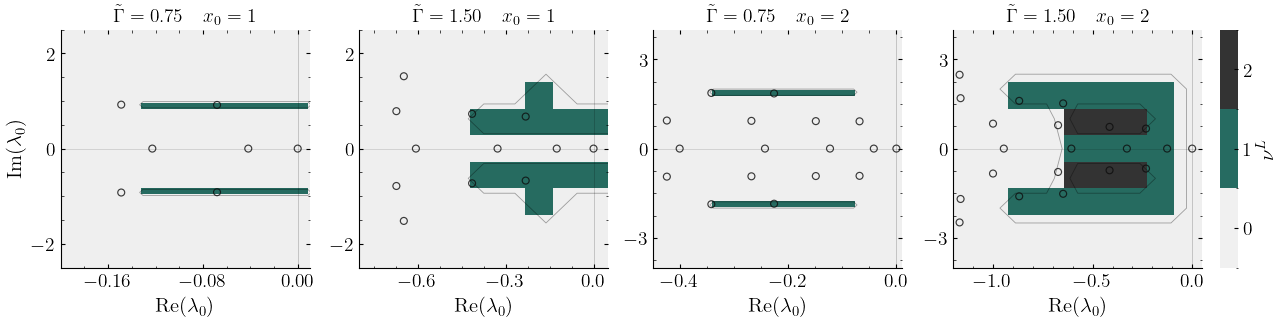

Saved figure: index_1x4_v4_10.pdf
Saved checkpoint: checkpoints_localizer/localizer_panels_20260303_110658.pkl


In [ ]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.cm import ScalarMappable
import scienceplots
from tqdm.auto import tqdm
import time
import os
import pickle
from pathlib import Path
from datetime import datetime

# Style
plt.style.use(["science"])
mpl.rcParams.update({
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
})


# Checkpoint config
CHECKPOINT_DIR = Path("checkpoints_localizer")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
CKPT_PATH = CHECKPOINT_DIR / f"localizer_panels_{RUN_TAG}.pkl"

def save_checkpoint(path: Path, payload: dict):
    tmp = path.with_suffix(".pkl.tmp")
    with open(tmp, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, path)  

def load_checkpoint(path: Path):
    with open(path, "rb") as f:
        return pickle.load(f)


X = build_rank_operator_from_casimir(K2_mat, j)

assert np.allclose(X, X.conj().T, atol=1e-8)
coord_label = r"$K_{\mathrm{rank}}$"

kappa    = 1.0
zero_tol = 1e-8


# Adaptive sweep (with tqdm + ETA)
def sweep_index_adaptive_on_window(
    L_mat: np.ndarray,
    x0: float,
    re_min: float, re_max: float,
    im_min: float, im_max: float,
    n_coarse: int = 30,
    n_refine: int = 8,
    refine_nonzero: bool = True,
    refine_edges: bool = True,
    pbar_desc: str = "",
):
    re_c = np.linspace(re_min, re_max, n_coarse)
    im_c = np.linspace(im_min, im_max, n_coarse)

    # (1) COARSE
    IDX_c = np.zeros((n_coarse, n_coarse), dtype=int)
    total_coarse = n_coarse * n_coarse

    t0 = time.perf_counter()
    pbar1 = tqdm(total=total_coarse, desc=f"{pbar_desc} coarse", leave=False)

    cnt = 0
    for yi, im0 in enumerate(im_c):
        for xi, re0 in enumerate(re_c):
            lam0 = re0 + 1j * im0
            L_loc = spectral_localizer(L_mat, X, lam0=lam0, x0=x0, kappa=kappa)
            _, IDX_c[yi, xi] = localizer_gap_and_index(L_loc, zero_tol=zero_tol)

            cnt += 1
            if (cnt % max(1, total_coarse // 200)) == 0:  # ~200 updates max
                elapsed = time.perf_counter() - t0
                rate = cnt / max(elapsed, 1e-12)
                eta = (total_coarse - cnt) / max(rate, 1e-12)
                pbar1.set_postfix_str(f"ETA {eta/60:.1f} min")
            pbar1.update(1)

    pbar1.close()

    # UPSAMPLE BG
    n_hi  = (n_coarse - 1) * n_refine + 1
    re_hi = np.linspace(re_min, re_max, n_hi)
    im_hi = np.linspace(im_min, im_max, n_hi)

    IDX_bg = np.repeat(np.repeat(IDX_c[:-1, :-1], n_refine, axis=0), n_refine, axis=1)
    IDX_hi = np.pad(IDX_bg, ((0, 1), (0, 1)), mode="edge")

    def cell_is_interesting(yi, xi):
        corners = np.array([
            IDX_c[yi,   xi],
            IDX_c[yi,   xi+1],
            IDX_c[yi+1, xi],
            IDX_c[yi+1, xi+1],
        ])
        if refine_nonzero and np.any(corners != 0):
            return True
        if refine_edges and (corners.max() != corners.min()):
            return True
        return False

    interesting = [(yi, xi) for yi in range(n_coarse - 1) for xi in range(n_coarse - 1)
                   if cell_is_interesting(yi, xi)]

    # REFINE
    t1 = time.perf_counter()
    pbar2 = tqdm(total=len(interesting), desc=f"{pbar_desc} refine tiles", leave=False)

    done = 0
    for yi, xi in interesting:
        re0, re1 = re_c[xi], re_c[xi+1]
        im0, im1 = im_c[yi], im_c[yi+1]

        re_f = np.linspace(re0, re1, n_refine + 1)
        im_f = np.linspace(im0, im1, n_refine + 1)

        patch = np.zeros((n_refine + 1, n_refine + 1), dtype=int)
        for fj, imv in enumerate(im_f):
            for fi, rev in enumerate(re_f):
                lam0 = rev + 1j * imv
                L_loc = spectral_localizer(L_mat, X, lam0=lam0, x0=x0, kappa=kappa)
                _, patch[fj, fi] = localizer_gap_and_index(L_loc, zero_tol=zero_tol)

        y0 = yi * n_refine
        x0i = xi * n_refine
        IDX_hi[y0:y0 + n_refine + 1, x0i:x0i + n_refine + 1] = patch

        done += 1
        if len(interesting) > 0 and (done % max(1, len(interesting) // 100)) == 0:
            elapsed = time.perf_counter() - t1
            rate = done / max(elapsed, 1e-12)
            eta = (len(interesting) - done) / max(rate, 1e-12)
            pbar2.set_postfix_str(f"ETA {eta/60:.1f} min")
        pbar2.update(1)

    pbar2.close()

    return IDX_hi, re_hi, im_hi

# PANEL SPECS
gL, gH = 0.75, 1.5
panel_specs = [
    dict(label="(a)", gamma=gL, x0=1.0, re=(-0.20, 0.02), im=(-2.5, 2.5), n_coarse=20, n_refine=2),
    dict(label="(b)", gamma=gH, x0=1.0, re=(-0.8, 0.05),  im=(-2.5, 2.5), n_coarse=9, n_refine=1),
    dict(label="(c)", gamma=gL, x0=2.0, re=(-0.45, 0.02), im=(-4, 4),     n_coarse=20, n_refine=2),
    dict(label="(d)", gamma=gH, x0=2.0, re=(-1.2, 0.05),  im=(-4, 4),      n_coarse=9, n_refine=1),
]

def spectrum_window(lam: np.ndarray, pad_frac: float = 0.15):
    re_min, re_max = lam.real.min(), lam.real.max()
    im_min, im_max = lam.imag.min(), lam.imag.max()
    pad_re = pad_frac * max(1e-12, (re_max - re_min))
    pad_im = pad_frac * max(1e-12, (im_max - im_min))
    return (re_min - pad_re, re_max + pad_re), (im_min - pad_im, im_max + pad_im)


# Compute all panels (tqdm + checkpoint after each panel)
panels = []
all_idx_vals = set()

panel_pbar = tqdm(panel_specs, desc="Panels (overall)", leave=True)
t_panels = time.perf_counter()

for i_spec, spec in enumerate(panel_pbar, start=1):
    g  = spec["gamma"]
    x0 = spec["x0"]

    panel_pbar.set_postfix_str(f"{spec['label']} Γ={g:.2f} x0={x0:.0f}")

    L_mat = build_liouvillian(omega, g)
    lam   = np.linalg.eigvals(L_mat)

    if spec["re"] is None or spec["im"] is None:
        (re_min, re_max), (im_min, im_max) = spectrum_window(lam, pad_frac=0.15)
    else:
        re_min, re_max = spec["re"]
        im_min, im_max = spec["im"]

    IDX, re_g, im_g = sweep_index_adaptive_on_window(
        L_mat=L_mat,
        x0=x0,
        re_min=re_min, re_max=re_max,
        im_min=im_min, im_max=im_max,
        n_coarse=spec["n_coarse"],
        n_refine=spec["n_refine"],
        refine_nonzero=True,
        refine_edges=True,
        pbar_desc=f"{spec['label']} Γ={g:.2f} x0={x0:.0f}",
    )

    for v in np.unique(IDX):
        all_idx_vals.add(int(v))

    panels.append(dict(
        spec=spec,
        IDX=IDX,
        re=re_g,
        im=im_g,
        lam=lam,
        window=(re_min, re_max, im_min, im_max),
    ))

    # checkpoint after each panel
    payload = {
        "run_tag": RUN_TAG,
        "N_spins": N_spins,
        "j": j,
        "omega": omega,
        "kappa": kappa,
        "zero_tol": zero_tol,
        "panel_specs": panel_specs,
        "panels_done": len(panels),
        "panels": panels,
        "all_idx_vals": sorted(all_idx_vals),
    }
    save_checkpoint(CKPT_PATH, payload)
  
    # overall ETA (panels)
    elapsed = time.perf_counter() - t_panels
    rate = len(panels) / max(elapsed, 1e-12)
    eta_panels = (len(panel_specs) - len(panels)) / max(rate, 1e-12)
    panel_pbar.set_postfix_str(f"saved {len(panels)}/{len(panel_specs)} | ETA {eta_panels/60:.1f} min")

panel_pbar.close()

idx_vals_sorted = np.array(sorted(all_idx_vals), dtype=int)
print("Index values appearing across all panels:", idx_vals_sorted)


# REMAP indices so colormap/norm only represent values that appear
idx_vals = idx_vals_sorted.tolist()
val_to_slot = {v: i for i, v in enumerate(idx_vals)}
m = len(idx_vals)

def remap_ID(IDX: np.ndarray) -> np.ndarray:
    out = np.empty_like(IDX, dtype=int)
    for v, s in val_to_slot.items():
        out[IDX == v] = s
    return out

palette = [
    (0.94, 0.94, 0.94, 1.0),  # light gray (for index 0)
    (0.15, 0.42, 0.38, 1.0),  # deep teal
    (0.20, 0.20, 0.20, 1.0),  # charcoal
]

if m > len(palette):
    tmp = plt.get_cmap("cividis", m)
    colors = [tmp(i) for i in range(m)]
else:
    colors = palette[:m]

if 0 in val_to_slot:
    colors[val_to_slot[0]] = (0.94, 0.94, 0.94, 1.0)

cmap = ListedColormap(colors)
bounds = np.arange(-0.5, m + 0.5, 1.0)
norm = BoundaryNorm(bounds, cmap.N)
contour_levels = np.arange(0.5, m, 1.0)

# Plot: 1x4 side-by-side + shared colorbar 
fig = plt.figure(figsize=(12.8, 3.2), constrained_layout=True)
gs  = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1, 1, 0.075], wspace=0.06, hspace=0.05)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[0, 3]),
]
cax = fig.add_subplot(gs[0, 4])

for ax, p in zip(axes, panels):
    spec = p["spec"]
    IDX  = p["IDX"]
    IDX_plot = remap_ID(IDX)

    re_g, im_g = p["re"], p["im"]
    lam = p["lam"]
    re_min, re_max, im_min, im_max = p["window"]

    imh = ax.imshow(
        IDX_plot,
        origin="lower",
        aspect="auto",
        extent=[re_g.min(), re_g.max(), im_g.min(), im_g.max()],
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        rasterized=True,
        zorder=0,
    )

    ax.axvline(0.0, color=(0, 0, 0, 0.18), lw=0.7, zorder=1)
    ax.axhline(0.0, color=(0, 0, 0, 0.12), lw=0.7, zorder=1)

    RR, II = np.meshgrid(re_g, im_g)
    ax.contour(
        RR, II, IDX_plot,
        levels=contour_levels,
        colors=[(0.0, 0.0, 0.0, 0.35)],
        linewidths=0.6,
        antialiased=True,
        zorder=2
    )

    mask = (
        (lam.real >= re_min) & (lam.real <= re_max) &
        (lam.imag >= im_min) & (lam.imag <= im_max)
    )
    ax.scatter(
        lam.real[mask], lam.imag[mask], s=25, alpha=0.8,
        facecolors="none",
        edgecolors=(0.05, 0.05, 0.05, 0.55),
        linewidths=0.85,
        clip_on=True,
        rasterized=True,
        zorder=3,
    )

    header = (
        rf"$\tilde\Gamma={spec['gamma']/omega:.2f}$"
        r"\quad"
        rf"$x_0={spec['x0']:.0f}$"
    )
    ax.set_title(header, fontsize=14, pad=6, loc="center")

    ax.tick_params(labelsize=8)
    ax.minorticks_on()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(r"Im($\lambda_0$)", fontsize=15)
for ax in axes[1:]:
    ax.set_ylabel("")

for ax in axes:
    ax.set_xlabel(r"Re($\lambda_0$)", fontsize=15)

# KEEP fixed limits
axes[0].set_xlim(-0.20, 0.0 + 1e-2); axes[0].set_ylim(-2.5, 2.5)
axes[1].set_xlim(-0.8, 0.05);        axes[1].set_ylim(-2.5, 2.5)
axes[2].set_xlim(-0.45, 0.0 + 1e-2); axes[2].set_ylim(-4, 4)
axes[3].set_xlim(-1.2, 0.05);        axes[3].set_ylim(-4, 4)

for ax in axes:
    ax.tick_params(labelsize=14)
    ax.xaxis.label.set_size(15)
    ax.yaxis.label.set_size(15)
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, ticks=np.arange(m))
cbar.ax.set_yticklabels([str(v) for v in idx_vals])
cbar.set_label(r"$\nu^L$", fontsize=15)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=14)

plt.show()
#fig.savefig(f"index_1x4_v4_{N_spins}.pdf", bbox_inches="tight")
print(f"Saved figure: index_1x4_v4_{N_spins}.pdf")
print(f"Saved checkpoint: {CKPT_PATH}")

## Faster Implementation

Unique k labels: [ 0  1  2  3  4  5  6  7  8  9 10]
Precomputing L_mat + eigvals per gamma...
Done.



Panels (overall):   0%|          | 0/4 [00:00<?, ?panel/s]


Computed 4 panels in 119.46s
Saved checkpoint: checkpoints_localizer/localizer_panels_20260303_132929.pkl
Index values appearing across all panels: [0 1 2]


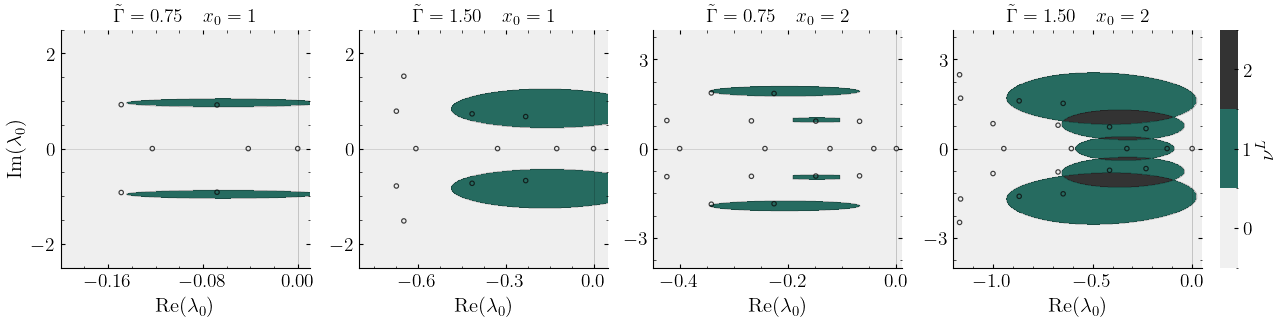

Saved figure: index_1x4_v4_fast_10.pdf
Saved checkpoint: checkpoints_localizer/localizer_panels_20260303_132929.pkl


In [ ]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.cm import ScalarMappable
import scienceplots

import scipy.linalg as sla
from joblib import Parallel, delayed
from tqdm.auto import tqdm

import time
import pickle
from pathlib import Path
from datetime import datetime
import subprocess
import contextlib

# Style
plt.style.use(["science"])
mpl.rcParams.update({
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
})


# Checkpoint config
CHECKPOINT_DIR = Path("checkpoints_localizer")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
CKPT_PATH = CHECKPOINT_DIR / f"localizer_panels_{RUN_TAG}.pkl"

def save_checkpoint(path: Path, payload: dict):
    tmp = path.with_suffix(".pkl.tmp")
    with open(tmp, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, path)


# tqdm <-> joblib bridge + panel ETA
@contextlib.contextmanager
def tqdm_joblib_with_panel_eta(tqdm_object, total_panels: int, t_start: float):
    from joblib.parallel import BatchCompletionCallBack
    import joblib.parallel

    old_cb = joblib.parallel.BatchCompletionCallBack

    class TqdmBatchCompletionCallBack(old_cb):
        def __call__(self, *args, **kwargs):
            # update bar by the number of jobs completed in this batch
            tqdm_object.update(n=self.batch_size)

            # compute ETA from observed throughput
            done = tqdm_object.n
            elapsed = time.perf_counter() - t_start
            rate = done / max(elapsed, 1e-12)
            eta = (total_panels - done) / max(rate, 1e-12)

            tqdm_object.set_postfix_str(
                f"saved {done}/{total_panels} | ETA {eta/60:.1f} min"
            )
            return super().__call__(*args, **kwargs)

    try:
        joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallBack
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_cb
        tqdm_object.close()


X = build_rank_operator_from_casimir(K2_mat, j)
assert np.allclose(X, X.conj().T, atol=1e-8)

kappa    = 1
zero_tol = 1e-8

class PanelLocalizerPrecomp:
    def __init__(self, L_mat: np.ndarray, X: np.ndarray, x0: float, kappa: float):
        self.N = int(L_mat.shape[0])
        self.kappa = float(kappa)
        self.x0 = float(x0)

        N = self.N
        Xh = 0.5 * (X + X.conj().T)

        TL = self.kappa * (Xh - self.x0 * np.eye(N, dtype=complex))
        BR = -TL

        TR0 = L_mat.astype(complex, copy=False)
        BL0 = TR0.conj().T

        M = np.empty((2*N, 2*N), dtype=complex)
        M[:N, :N] = TL
        M[N:, N:] = BR
        M[:N, N:] = TR0
        M[N:, :N] = BL0

        self.M = M
        self._lam0_current = 0.0 + 0.0j

        ii = np.arange(N)
        self._diag_TR = (ii, N + ii)
        self._diag_BL = (N + ii, ii)

    def set_lam0(self, lam0: complex):
        lam0 = complex(lam0)
        dlam = lam0 - self._lam0_current
        if dlam == 0.0:
            return
        self.M[self._diag_TR] -= dlam
        self.M[self._diag_BL] -= np.conj(dlam)
        self._lam0_current = lam0

    def index_at(self, lam0: complex, zero_tol: float) -> int:
        self.set_lam0(lam0)
        return localizer_index_ldl(self.M, zero_tol=zero_tol)

# Adaptive sweep
def sweep_index_adaptive_on_window_fast(
    L_mat: np.ndarray,
    X: np.ndarray,
    x0: float,
    re_min: float, re_max: float,
    im_min: float, im_max: float,
    n_coarse: int,
    n_refine: int,
    refine_nonzero: bool = True,
    refine_edges: bool = True,
):
    pre = PanelLocalizerPrecomp(L_mat, X, x0=x0, kappa=kappa)

    re_c = np.linspace(re_min, re_max, n_coarse)
    im_c = np.linspace(im_min, im_max, n_coarse)

    # COARSE
    IDX_c = np.zeros((n_coarse, n_coarse), dtype=int)
    for yi, im0 in enumerate(im_c):
        for xi, re0 in enumerate(re_c):
            IDX_c[yi, xi] = pre.index_at(re0 + 1j * im0, zero_tol=zero_tol)

    # UPSAMPLE BG
    n_hi  = (n_coarse - 1) * n_refine + 1
    re_hi = np.linspace(re_min, re_max, n_hi)
    im_hi = np.linspace(im_min, im_max, n_hi)

    IDX_bg = np.repeat(np.repeat(IDX_c[:-1, :-1], n_refine, axis=0), n_refine, axis=1)
    IDX_hi = np.pad(IDX_bg, ((0, 1), (0, 1)), mode="edge")

    def cell_is_interesting(yi, xi):
        corners = np.array([IDX_c[yi,xi], IDX_c[yi,xi+1], IDX_c[yi+1,xi], IDX_c[yi+1,xi+1]])
        if refine_nonzero and np.any(corners != 0):
            return True
        if refine_edges and (corners.max() != corners.min()):
            return True
        return False

    interesting = [(yi, xi) for yi in range(n_coarse - 1) for xi in range(n_coarse - 1)
                   if cell_is_interesting(yi, xi)]

    # REFINE
    for yi, xi in interesting:
        re0, re1 = re_c[xi], re_c[xi+1]
        im0, im1 = im_c[yi], im_c[yi+1]

        re_f = np.linspace(re0, re1, n_refine + 1)
        im_f = np.linspace(im0, im1, n_refine + 1)

        patch = np.zeros((n_refine + 1, n_refine + 1), dtype=int)
        for fj, imv in enumerate(im_f):
            for fi, rev in enumerate(re_f):
                patch[fj, fi] = pre.index_at(rev + 1j * imv, zero_tol=zero_tol)

        y0 = yi * n_refine
        x0i = xi * n_refine
        IDX_hi[y0:y0 + n_refine + 1, x0i:x0i + n_refine + 1] = patch

    return IDX_hi, re_hi, im_hi

# Panel specs
gL, gH = 0.75, 1.5
panel_specs = [
    dict(label="(a)", gamma=gL, x0=1.0, re=(-0.20, 0.02), im=(-2.5, 2.5), n_coarse=50, n_refine=20),
    dict(label="(b)", gamma=gH, x0=1.0, re=(-0.8, 0.05),  im=(-2.5, 2.5), n_coarse=50,  n_refine=10),
    dict(label="(c)", gamma=gL, x0=2.0, re=(-0.45, 0.02), im=(-4, 4),     n_coarse=50, n_refine=20),
    dict(label="(d)", gamma=gH, x0=2.0, re=(-1.2, 0.05),  im=(-4, 4),      n_coarse=50,  n_refine=10),
]

def spectrum_window(lam: np.ndarray, pad_frac: float = 0.15):
    re_min, re_max = lam.real.min(), lam.real.max()
    im_min, im_max = lam.imag.min(), lam.imag.max()
    pad_re = pad_frac * max(1e-12, (re_max - re_min))
    pad_im = pad_frac * max(1e-12, (im_max - im_min))
    return (re_min - pad_re, re_max + pad_re), (im_min - pad_im, im_max + pad_im)

# Cache L and eigvals per gamma
unique_gammas = sorted({spec["gamma"] for spec in panel_specs})
L_cache = {}
print("Precomputing L_mat + eigvals per gamma...")
for g in unique_gammas:
    L_mat = build_liouvillian(omega, g)
    lam   = np.linalg.eigvals(L_mat)
    L_cache[g] = (L_mat, lam)
print("Done.\n")


# Panel worker
def compute_one_panel_numpy(spec, L_mat, lam, X, kappa, zero_tol):
    g  = float(spec["gamma"])
    x0 = float(spec["x0"])

    if spec.get("re") is None or spec.get("im") is None:
        (re_min, re_max), (im_min, im_max) = spectrum_window(lam, pad_frac=0.15)
    else:
        re_min, re_max = spec["re"]
        im_min, im_max = spec["im"]

    IDX, re_g, im_g = sweep_index_adaptive_on_window_fast(
        L_mat=L_mat,
        X=X,
        x0=x0,
        re_min=re_min, re_max=re_max,
        im_min=im_min, im_max=im_max,
        n_coarse=int(spec["n_coarse"]),
        n_refine=int(spec["n_refine"]),
        refine_nonzero=True,
        refine_edges=True,
    )

    uniq = sorted(set(map(int, np.unique(IDX))))

    return dict(
        spec=spec,
        IDX=IDX,
        re=re_g,
        im=im_g,
        lam=lam,
        window=(re_min, re_max, im_min, im_max),
        uniq=uniq,
    )


# Compute panels in parallel (joblib loky) + progress + checkpoint each job
results = []
all_idx_vals = set()

# We compute in parallel, but we want checkpointing as results arrive.
t0 = time.perf_counter()

pbar = tqdm(
    total=len(panel_specs),
    desc="Panels (overall)",
    unit="panel",
    leave=True,
    dynamic_ncols=True, 
    smoothing=0.05,
)

with tqdm_joblib_with_panel_eta(pbar, total_panels=len(panel_specs), t_start=t0):
    results = Parallel(
        n_jobs=-1,
        backend="loky",
        prefer="processes",
        batch_size=1,   # keep 1 for smooth 'saved i/N'
    )(
        delayed(compute_one_panel_numpy)(
            spec,
            L_cache[spec["gamma"]][0],
            L_cache[spec["gamma"]][1],
            X, kappa, zero_tol
        )
        for spec in panel_specs
    )
# Now checkpoint once
for p in results:
    for v in p["uniq"]:
        all_idx_vals.add(int(v))

payload = {
    "run_tag": RUN_TAG,
    "N_spins": N_spins,
    "j": j,
    "omega_x": omega,
    "kappa": kappa,
    "zero_tol": zero_tol,
    "panel_specs": panel_specs,
    "panels_done": len(results),
    "panels": results,
    "all_idx_vals": sorted(all_idx_vals),
}
save_checkpoint(CKPT_PATH, payload)

elapsed = time.perf_counter() - t0
print(f"\nComputed {len(results)} panels in {elapsed:.2f}s")
print(f"Saved checkpoint: {CKPT_PATH}")


# Rebuild panels in original order
panels = []
for p in results:
    panels.append(dict(
        spec=p["spec"],
        IDX=p["IDX"],
        re=p["re"],
        im=p["im"],
        lam=p["lam"],
        window=p["window"],
    ))

idx_vals_sorted = np.array(sorted(all_idx_vals), dtype=int)
print("Index values appearing across all panels:", idx_vals_sorted)

# Remap indices so colormap/norm only represent values that appear
idx_vals = idx_vals_sorted.tolist()
val_to_slot = {v: i for i, v in enumerate(idx_vals)}
m = len(idx_vals)

def remap_ID(IDX: np.ndarray) -> np.ndarray:
    out = np.empty_like(IDX, dtype=int)
    for v, s in val_to_slot.items():
        out[IDX == v] = s
    return out

palette = [
    (0.94, 0.94, 0.94, 1.0),  # light gray
    (0.15, 0.42, 0.38, 1.0),  # teal
    (0.20, 0.20, 0.20, 1.0),  # charcoal
    (0.55, 0.27, 0.27, 1.0),  # brick
    (0.36, 0.28, 0.50, 1.0),  # purple
    (0.45, 0.45, 0.20, 1.0),  # olive
]
if m > len(palette):
    tmp = plt.get_cmap("cividis", m)
    colors = [tmp(i) for i in range(m)]
else:
    colors = palette[:m]

if 0 in val_to_slot:
    colors[val_to_slot[0]] = (0.94, 0.94, 0.94, 1.0)

cmap = ListedColormap(colors)
bounds = np.arange(-0.5, m + 0.5, 1.0)
norm = BoundaryNorm(bounds, cmap.N)
contour_levels = np.arange(0.5, m, 1.0)

# Plot: 1x4 side-by-side + shared colorbar
fig = plt.figure(figsize=(12.8, 3.2), constrained_layout=True)
gs  = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1, 1, 0.075], wspace=0.06, hspace=0.05)

axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
cax  = fig.add_subplot(gs[0, 4])

for ax, p in zip(axes, panels):
    spec = p["spec"]
    IDX_plot = remap_ID(p["IDX"])

    re_g, im_g = p["re"], p["im"]
    lam = p["lam"]
    re_min, re_max, im_min, im_max = p["window"]

    ax.imshow(
        IDX_plot,
        origin="lower",
        aspect="auto",
        extent=[re_g.min(), re_g.max(), im_g.min(), im_g.max()],
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        rasterized=True,
        zorder=0,
    )

    ax.axvline(0.0, color=(0, 0, 0, 0.18), lw=0.7, zorder=1)
    ax.axhline(0.0, color=(0, 0, 0, 0.12), lw=0.7, zorder=1)

    RR, II = np.meshgrid(re_g, im_g)
    ax.contour(
        RR, II, IDX_plot,
        levels=contour_levels,
        colors=[(0.0, 0.0, 0.0, 0.35)],
        linewidths=0.6,
        antialiased=True,
        zorder=2
    )

    mask = (
        (lam.real >= re_min) & (lam.real <= re_max) &
        (lam.imag >= im_min) & (lam.imag <= im_max)
    )
    ax.scatter(
        lam.real[mask], lam.imag[mask], s=10, alpha=0.8,
        facecolors="none",
        edgecolors=(0.05, 0.05, 0.05, 0.55),
        linewidths=0.85,
        clip_on=True,
        rasterized=True,
        zorder=3,
    )

    header = rf"$\tilde\Gamma={spec['gamma']/omega:.2f}$" + r"\quad" + rf"$x_0={spec['x0']:.0f}$"
    ax.set_title(header, fontsize=14, pad=6, loc="center")

    ax.minorticks_on()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(r"Im($\lambda_0$)", fontsize=15)
for ax in axes:
    ax.set_xlabel(r"Re($\lambda_0$)", fontsize=15)

# your fixed limits
axes[0].set_xlim(-0.20, 0.0 + 1e-2); axes[0].set_ylim(-2.5, 2.5)
axes[1].set_xlim(-0.8, 0.05);        axes[1].set_ylim(-2.5, 2.5)
axes[2].set_xlim(-0.45, 0.0 + 1e-2); axes[2].set_ylim(-4, 4)
axes[3].set_xlim(-1.2, 0.05);        axes[3].set_ylim(-4, 4)

for ax in axes:
    ax.tick_params(labelsize=14)
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax, ticks=np.arange(m))
cbar.ax.set_yticklabels([str(v) for v in idx_vals])
cbar.set_label(r"$\nu^L$", fontsize=15)
cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=14)

plt.show()

out_pdf = f"index_1x4_v4_fast_{N_spins}.pdf"
#fig.savefig(out_pdf, bbox_inches="tight")
print(f"Saved figure: {out_pdf}")
print(f"Saved checkpoint: {CKPT_PATH}")